<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/01_foundations/probability_statistics/experiment_probability_statistics_simulations_and_distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Simulating Coin Toss (Law of Large Numbers)

Write a Python program to simulate 5000 coin tosses.
Estimate the probability of heads and show how it converges toward 0.5 as the number of trials
increases.



Estimated Probability of Heads after 5000 tosses: 0.4892


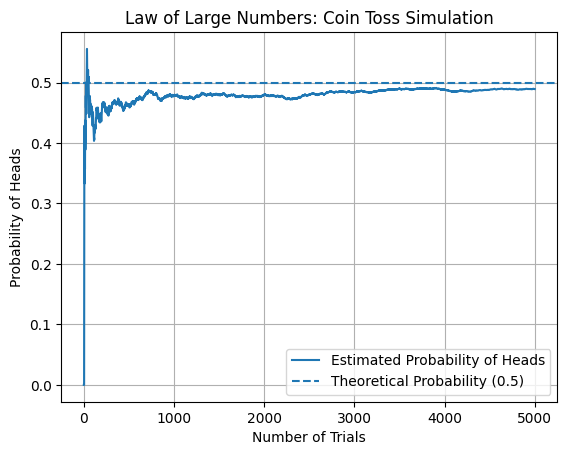

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Total number of tosses
n_trials = 5000

# Simulate coin tosses: 1 = Heads, 0 = Tails
tosses = np.random.randint(0, 2, n_trials)

# Cumulative number of heads
cumulative_heads = np.cumsum(tosses)

# Trial numbers
trials = np.arange(1, n_trials + 1)

# Estimated probability of heads at each step
prob_heads = cumulative_heads / trials

# Final estimated probability
print(f"Estimated Probability of Heads after {n_trials} tosses: {prob_heads[-1]:.4f}")

# Plotting the convergence
plt.figure()
plt.plot(trials, prob_heads, label="Estimated Probability of Heads")
plt.axhline(y=0.5, linestyle='--', label="Theoretical Probability (0.5)")
plt.xlabel("Number of Trials")
plt.ylabel("Probability of Heads")
plt.title("Law of Large Numbers: Coin Toss Simulation")
plt.legend()
plt.grid()

plt.show()


2. Dice Simulation & Probability Estimation

Simulate 10,000 dice rolls.
Calculate and display the empirical probability of each outcome (1–6).
Plot the frequency distribution using a bar chart.


Outcome 1: Count = 1672, Probability = 0.1672
Outcome 2: Count = 1717, Probability = 0.1717
Outcome 3: Count = 1639, Probability = 0.1639
Outcome 4: Count = 1714, Probability = 0.1714
Outcome 5: Count = 1590, Probability = 0.1590
Outcome 6: Count = 1668, Probability = 0.1668


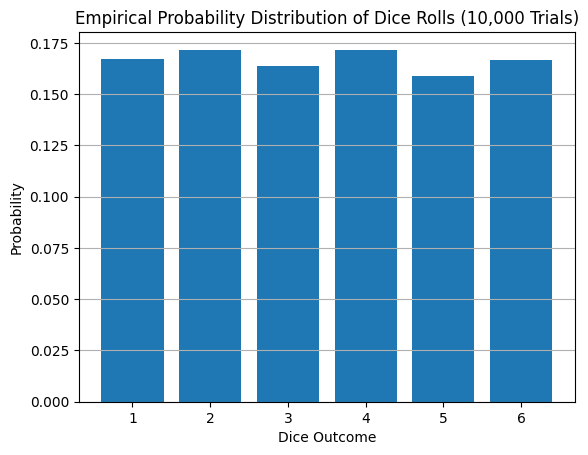

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Total number of rolls
n_rolls = 10000

# Simulate dice rolls (1 to 6)
rolls = np.random.randint(1, 7, n_rolls)

# Count frequency of each outcome
counts = [np.sum(rolls == i) for i in range(1, 7)]

# Empirical probabilities
probabilities = [count / n_rolls for count in counts]

# Display results
for i in range(6):
    print(f"Outcome {i+1}: Count = {counts[i]}, Probability = {probabilities[i]:.4f}")

# Plot bar chart
outcomes = [1, 2, 3, 4, 5, 6]

plt.figure()
plt.bar(outcomes, probabilities)
plt.xlabel("Dice Outcome")
plt.ylabel("Probability")
plt.title("Empirical Probability Distribution of Dice Rolls (10,000 Trials)")
plt.xticks(outcomes)
plt.grid(axis='y')

plt.show()


3. Bayes Theorem – Medical Diagnosis

Write a Python program to compute posterior probability using Bayes’ theorem for:

*   P(Disease) = 0.02
*   P(Positive | Disease) = 0.95

*   P(Positive |No Disease) = 0.08

Interpret the result.

In [ ]:
# Given probabilities
P_D = 0.02                  # P(Disease)
P_not_D = 1 - P_D           # P(No Disease)

P_pos_given_D = 0.95        # P(Positive | Disease)
P_pos_given_not_D = 0.08    # P(Positive | No Disease)

# Total probability of testing positive
P_pos = (P_pos_given_D * P_D) + (P_pos_given_not_D * P_not_D)

# Bayes' Theorem
P_D_given_pos = (P_pos_given_D * P_D) / P_pos

# Output
print(f"Probability of Disease given Positive Test: {P_D_given_pos:.4f}")


Probability of Disease given Positive Test: 0.1951


4. Naive Bayes Implementation

Implement a simple Naive Bayes classifier manually (without sklearn) for a small binary
dataset and classify a new sample.

In [ ]:
import numpy as np

# Dataset
X = np.array([
    [1, 1],
    [1, 0],
    [0, 1],
    [0, 0]
])

y = np.array(["Yes", "Yes", "No", "No"])

# Step 1: Calculate Prior Probabilities
classes = np.unique(y)
priors = {}

for c in classes:
    priors[c] = np.sum(y == c) / len(y)

# Step 2: Calculate Likelihoods P(feature | class)
likelihoods = {}

for c in classes:
    X_c = X[y == c]
    likelihoods[c] = {}

    for feature_index in range(X.shape[1]):
        likelihoods[c][feature_index] = {}

        for value in [0, 1]:
            count = np.sum(X_c[:, feature_index] == value)
            likelihoods[c][feature_index][value] = count / len(X_c)

# Step 3: Prediction Function
def predict(sample):
    posteriors = {}

    for c in classes:
        posterior = priors[c]

        for feature_index, feature_value in enumerate(sample):
            posterior *= likelihoods[c][feature_index][feature_value]

        posteriors[c] = posterior

    return max(posteriors, key=posteriors.get), posteriors

# Test sample
sample = [1, 1]
prediction, probs = predict(sample)

print("Posterior Probabilities:", probs)
print("Predicted Class:", prediction)


Posterior Probabilities: {np.str_('No'): np.float64(0.0), np.str_('Yes'): np.float64(0.25)}
Predicted Class: Yes


5. Histogram Visualization of Distributions
Generate:

*   2000 random samples from Uniform distribution
*   2000 random samples from Normal distribution

Plot histograms and compare their shapes.


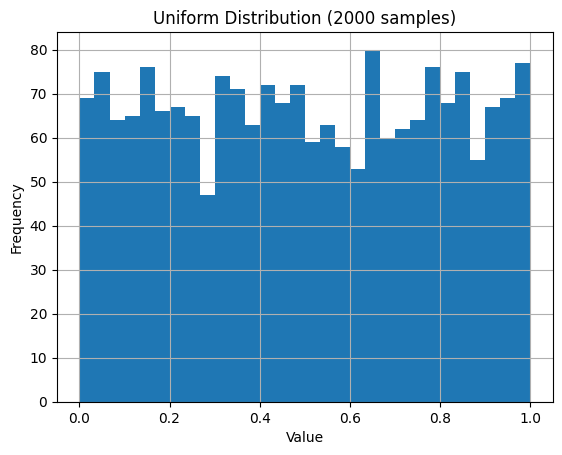

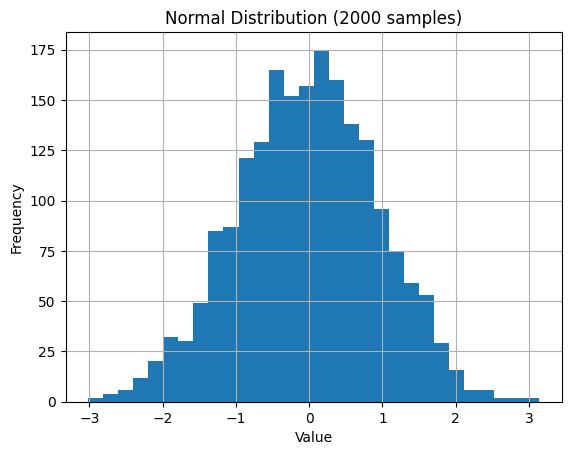

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate samples
uniform_data = np.random.uniform(0, 1, 2000)
normal_data = np.random.normal(0, 1, 2000)

# Plot Uniform Distribution Histogram
plt.figure()
plt.hist(uniform_data, bins=30)
plt.title("Uniform Distribution (2000 samples)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# Plot Normal Distribution Histogram
plt.figure()
plt.hist(normal_data, bins=30)
plt.title("Normal Distribution (2000 samples)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid()
plt.show()


6. Plotting PDF and CDF
Write a Python program to:

*   Plot the PDF of a Normal distribution (mean=0, std=1)
*   Plot the corresponding CDF

Interpret the difference.


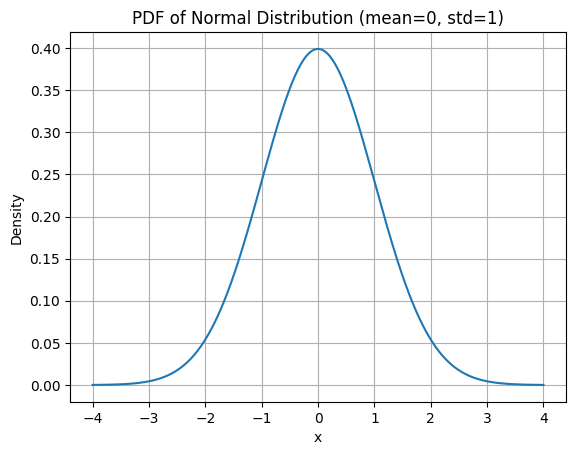

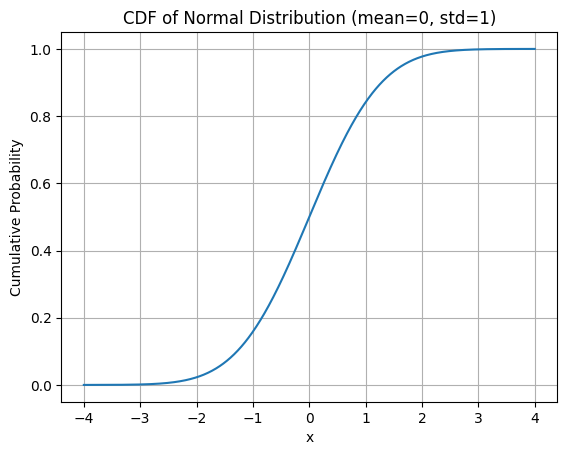

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mean = 0
std = 1

# X values
x = np.linspace(-4, 4, 1000)

# PDF and CDF
pdf = norm.pdf(x, mean, std)
cdf = norm.cdf(x, mean, std)

# Plot PDF
plt.figure()
plt.plot(x, pdf)
plt.title("PDF of Normal Distribution (mean=0, std=1)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid()
plt.show()

# Plot CDF
plt.figure()
plt.plot(x, cdf)
plt.title("CDF of Normal Distribution (mean=0, std=1)")
plt.xlabel("x")
plt.ylabel("Cumulative Probability")
plt.grid()
plt.show()


7. Distribution Fitting to Real Data
Load a real dataset (e.g., Iris dataset).
Select one feature and:

*   Plot histogram

*   Fit a Normal distribution
*   Overlay fitted curve


Comment whether data follows normal distribution.

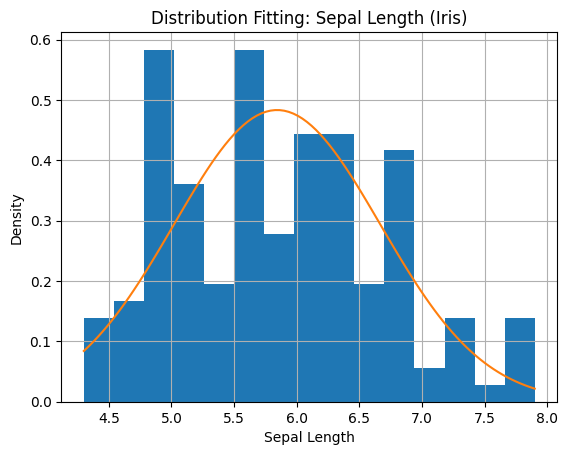

Estimated Mean: 5.8433
Estimated Std Dev: 0.8253


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.stats import norm

# Load dataset
iris = load_iris()
data = iris.data

# Select one feature (Sepal Length)
feature = data[:, 0]   # column 0 = sepal length

# Estimate mean and standard deviation
mean = np.mean(feature)
std = np.std(feature)

# Plot Histogram (density=True for PDF comparison)
plt.figure()
plt.hist(feature, bins=15, density=True)

# Create x values for fitted curve
x = np.linspace(min(feature), max(feature), 100)

# Fitted Normal distribution
fitted_pdf = norm.pdf(x, mean, std)

# Overlay fitted curve
plt.plot(x, fitted_pdf)

plt.title("Distribution Fitting: Sepal Length (Iris)")
plt.xlabel("Sepal Length")
plt.ylabel("Density")
plt.grid()

plt.show()

print(f"Estimated Mean: {mean:.4f}")
print(f"Estimated Std Dev: {std:.4f}")


8. Simulating Binomial Distribution
Simulate a Binomial distribution with:

*   n = 10
*   p = 0.5


Generate 5000 samples.

Compare empirical mean with theoretical mean.

Empirical Mean: 4.9996
Theoretical Mean: 5.0000


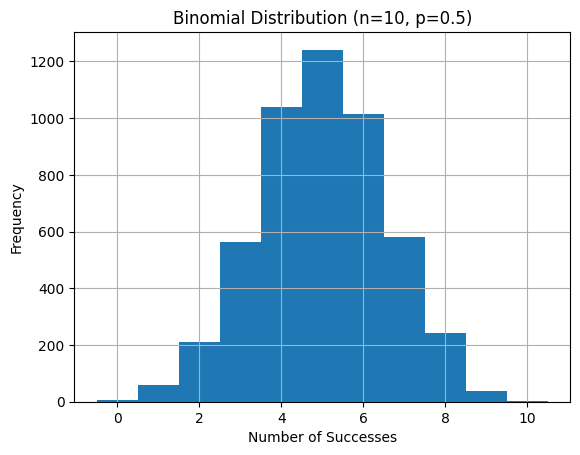

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 10
p = 0.5
num_samples = 5000

# Generate Binomial samples
samples = np.random.binomial(n, p, num_samples)

# Empirical mean
empirical_mean = np.mean(samples)

# Theoretical mean
theoretical_mean = n * p

# Output
print(f"Empirical Mean: {empirical_mean:.4f}")
print(f"Theoretical Mean: {theoretical_mean:.4f}")

# Plot histogram
plt.figure()
plt.hist(samples, bins=range(0, n+2), align='left')
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.title("Binomial Distribution (n=10, p=0.5)")
plt.grid()

plt.show()


9. Poisson Distribution – Event Modeling
Simulate a Poisson distribution with λ = 4.
Plot histogram and interpret how it models event occurrence (e.g., number of customer
arrivals).


Empirical Mean: 3.9936
Theoretical Mean (λ): 4


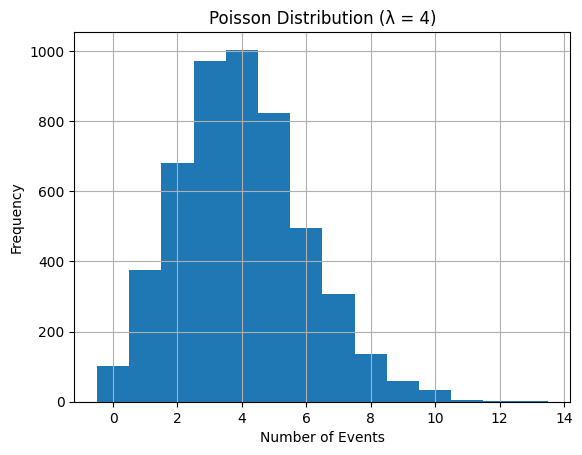

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
lam = 4
num_samples = 5000

# Generate Poisson samples
samples = np.random.poisson(lam, num_samples)

# Empirical mean
empirical_mean = np.mean(samples)

print(f"Empirical Mean: {empirical_mean:.4f}")
print(f"Theoretical Mean (λ): {lam}")

# Plot histogram
plt.figure()
plt.hist(samples, bins=range(0, max(samples)+2), align='left')
plt.xlabel("Number of Events")
plt.ylabel("Frequency")
plt.title("Poisson Distribution (λ = 4)")
plt.grid()

plt.show()


10. Monte Carlo Simulation for Classification Error
Simulate a binary classification scenario with probability of error = 0.1.
Run 10,000 trials and estimate empirical error rate.
Compare with theoretical value.

Empirical Error Rate: 0.1004
Theoretical Error Rate: 0.1000


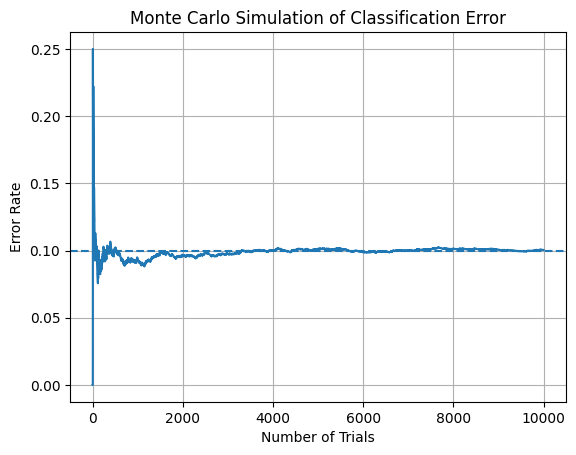

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
p_error = 0.1
n_trials = 10000

# Simulate errors: 1 = error, 0 = correct
errors = np.random.binomial(1, p_error, n_trials)

# Empirical error rate
empirical_error = np.mean(errors)

# Theoretical error
theoretical_error = p_error

print(f"Empirical Error Rate: {empirical_error:.4f}")
print(f"Theoretical Error Rate: {theoretical_error:.4f}")

# Cumulative error rate (to show convergence)
cumulative_error = np.cumsum(errors) / np.arange(1, n_trials + 1)

# Plot convergence
plt.figure()
plt.plot(cumulative_error)
plt.axhline(y=p_error, linestyle='--')
plt.xlabel("Number of Trials")
plt.ylabel("Error Rate")
plt.title("Monte Carlo Simulation of Classification Error")
plt.grid()

plt.show()
